In [1]:
import os
os.chdir(r"D:\Projects\Poverty Predictor Bd")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import os

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/maps", exist_ok=True)

df  = pd.read_csv("data/processed/master_features.csv")
gdf = gpd.read_file("data/processed/master_features.gpkg")

print(f"Loaded: {df.shape}")
print(df[['district_name','division_name','poverty_hcr']].to_string())

Loaded: (64, 26)
       district_name division_name  poverty_hcr
0            Barguna      Barishal         26.9
1           Barishal      Barishal         26.9
2              Bhola      Barishal         26.9
3          Jhalokati      Barishal         26.9
4         Patuakhali      Barishal         26.9
5           Pirojpur      Barishal         26.9
6          Bandarban    Chattogram         15.8
7       Brahmanbaria    Chattogram         15.8
8           Chandpur    Chattogram         15.8
9         Chattogram    Chattogram         15.8
10           Cumilla    Chattogram         15.8
11       Cox's Bazar    Chattogram         15.8
12              Feni    Chattogram         15.8
13      Khagrachhari    Chattogram         15.8
14        Lakshmipur    Chattogram         15.8
15          Noakhali    Chattogram         15.8
16         Rangamati    Chattogram         15.8
17             Dhaka         Dhaka         17.9
18          Faridpur         Dhaka         17.9
19           Gazipur   

In [2]:
feature_cols = ['ntl_mean', 'ntl_per_capita', 'urban_fraction', 
                'pop_density', 'ndvi_mean', 'road_density']

# Calculate coefficient of variation (std/mean) within each division
# High CV = features vary a lot within division despite same poverty label
cv_within = df.groupby('division_name')[feature_cols].apply(
    lambda x: (x.std() / x.mean()).round(3)
)

print("Coefficient of Variation WITHIN divisions")
print("(how much features differ between districts of same division)")
print("High value = lots of within-division variation\n")
print(cv_within.to_string())

print("\n\nMean feature values BY DIVISION:")
print(df.groupby('division_name')[feature_cols + ['poverty_hcr']].mean().round(3).to_string())

Coefficient of Variation WITHIN divisions
(how much features differ between districts of same division)
High value = lots of within-division variation

               ntl_mean  ntl_per_capita  urban_fraction  pop_density  ndvi_mean  road_density
division_name                                                                                
Barishal          0.098           0.217           0.362        0.189      0.135         0.405
Chattogram        0.556           0.913           0.935        0.581      0.136         0.702
Dhaka             1.074           0.202           1.634        1.169      0.087         0.894
Khulna            0.191           0.314           0.953        0.303      0.066         0.508
Mymensingh        0.226           0.122           0.427        0.174      0.094         0.316
Rajshahi          0.137           0.144           0.479        0.194      0.058         0.191
Rangpur           0.141           0.267           0.697        0.192      0.083         0.367
Sy

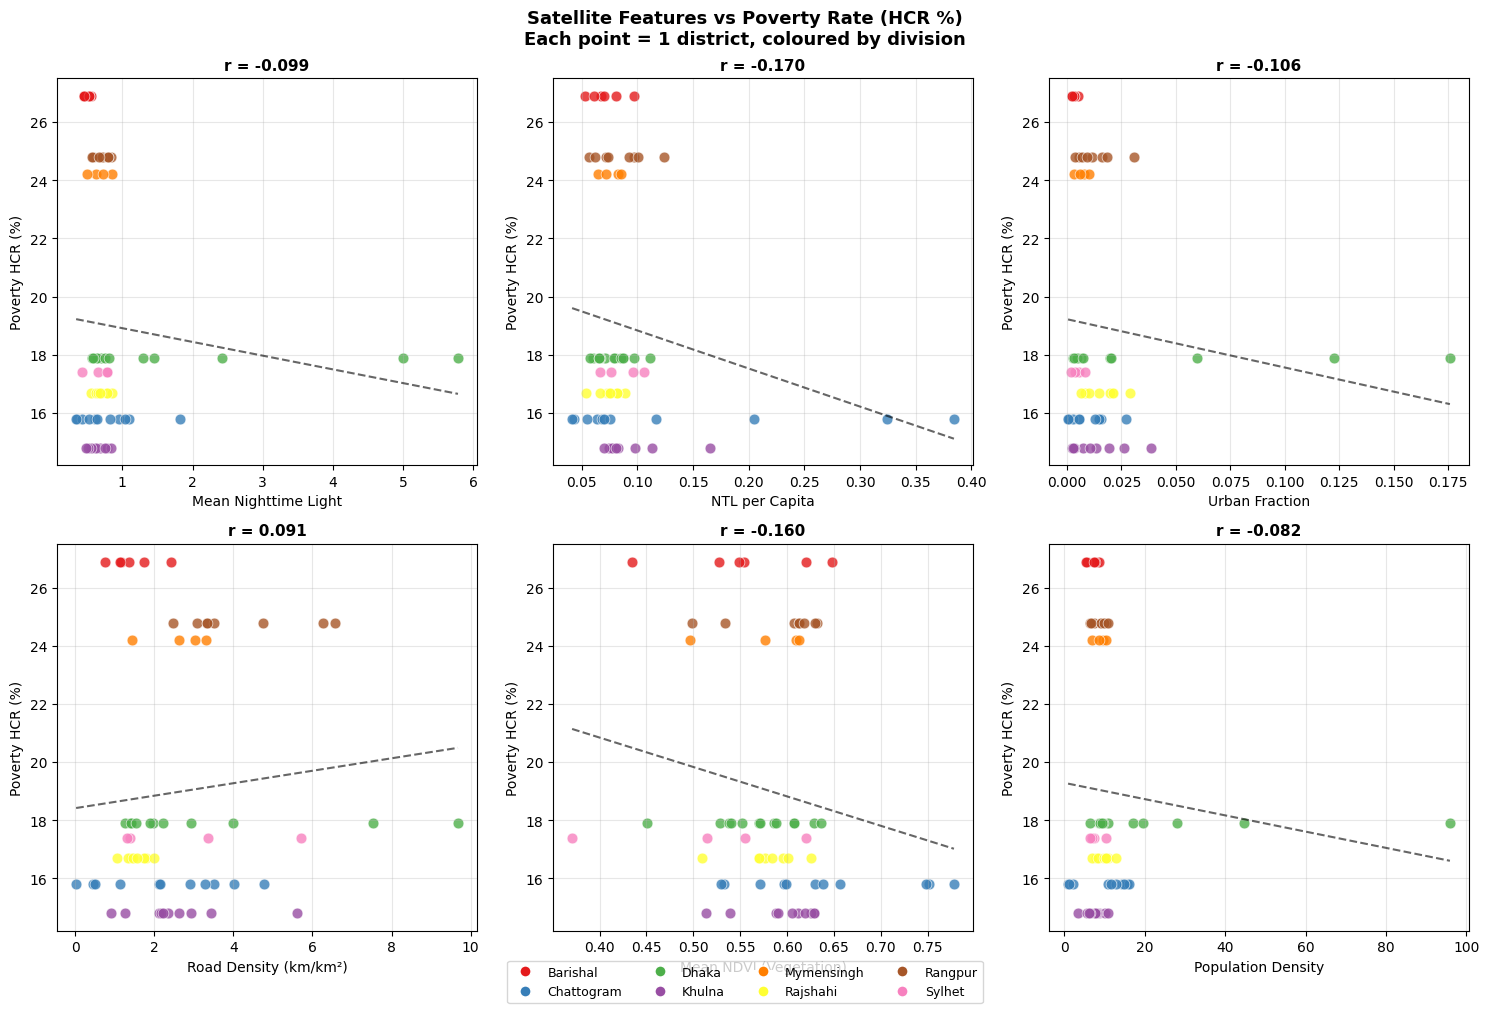

Saved: outputs/figures/feature_vs_poverty_scatter.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Satellite Features vs Poverty Rate (HCR %)\nEach point = 1 district, coloured by division', 
             fontsize=13, fontweight='bold')

features = [
    ('ntl_mean',       'Mean Nighttime Light'),
    ('ntl_per_capita', 'NTL per Capita'),
    ('urban_fraction', 'Urban Fraction'),
    ('road_density',   'Road Density (km/km²)'),
    ('ndvi_mean',      'Mean NDVI (Vegetation)'),
    ('pop_density',    'Population Density'),
]

divisions = df['division_name'].unique()
colors = plt.cm.Set1.colors
div_color = {div: colors[i] for i, div in enumerate(divisions)}

for ax, (feat, label) in zip(axes.flatten(), features):
    for div in divisions:
        sub = df[df['division_name'] == div]
        ax.scatter(sub[feat], sub['poverty_hcr'], 
                   color=div_color[div], label=div, 
                   alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
    
    # Correlation line
    z = np.polyfit(df[feat], df['poverty_hcr'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, alpha=0.6)
    
    # Pearson r
    r = df[feat].corr(df['poverty_hcr'])
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Poverty HCR (%)', fontsize=10)
    ax.set_title(f'r = {r:.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Single legend
handles = [plt.Line2D([0],[0], marker='o', color='w', 
           markerfacecolor=div_color[d], markersize=8, label=d) 
           for d in divisions]
fig.legend(handles=handles, loc='lower center', ncol=4, 
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("outputs/figures/feature_vs_poverty_scatter.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/feature_vs_poverty_scatter.png")

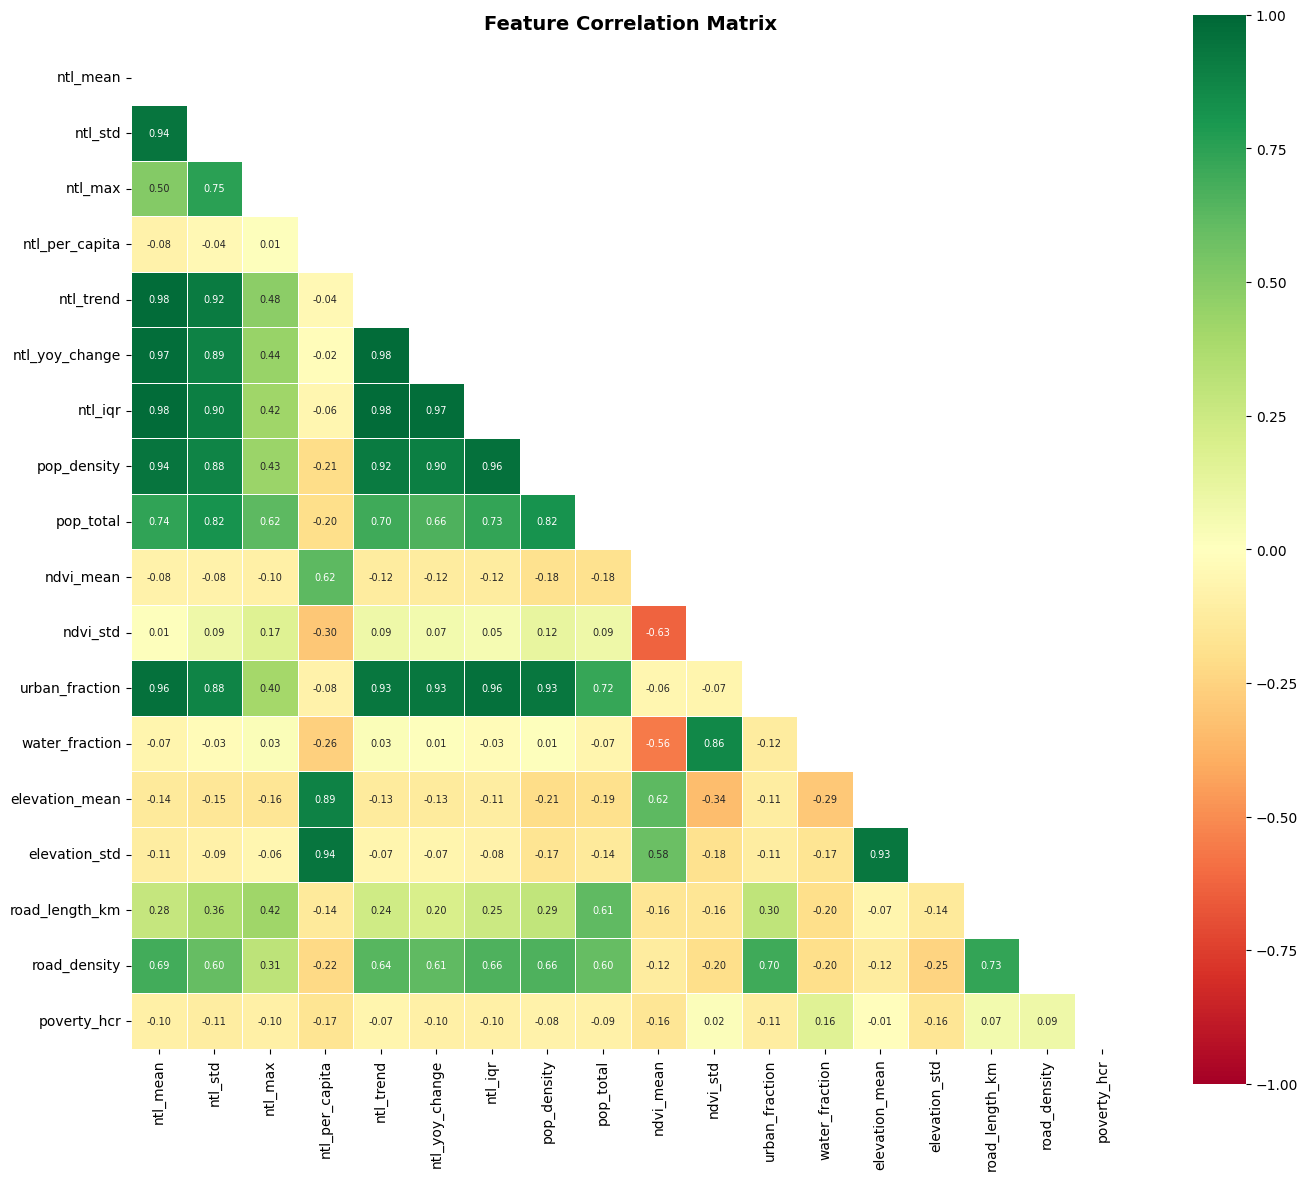


Correlations with poverty_hcr (sorted):
  ntl_per_capita            -0.170  -███
  ndvi_mean                 -0.160  -███
  elevation_std             -0.160  -███
  ntl_std                   -0.110  -██
  urban_fraction            -0.110  -██
  ntl_yoy_change            -0.100  -██
  ntl_mean                  -0.100  -██
  ntl_max                   -0.100  -██
  ntl_iqr                   -0.100  -██
  pop_total                 -0.090  -█
  pop_density               -0.080  -█
  ntl_trend                 -0.070  -█
  elevation_mean            -0.010  -
  ndvi_std                  +0.020  +
  road_length_km            +0.070  +█
  road_density              +0.090  +█
  water_fraction            +0.160  +███


In [4]:
feature_cols = [
    'ntl_mean', 'ntl_std', 'ntl_max', 'ntl_per_capita',
    'ntl_trend', 'ntl_yoy_change', 'ntl_iqr',
    'pop_density', 'pop_total',
    'ndvi_mean', 'ndvi_std',
    'urban_fraction', 'water_fraction',
    'elevation_mean', 'elevation_std',
    'road_length_km', 'road_density',
    'poverty_hcr'
]

corr = df[feature_cols].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("outputs/figures/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with poverty specifically, sorted
print("\nCorrelations with poverty_hcr (sorted):")
poverty_corr = corr['poverty_hcr'].drop('poverty_hcr').sort_values()
for feat, val in poverty_corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '-' if val < 0 else '+'
    print(f"  {feat:25} {val:+.3f}  {direction}{bar}")

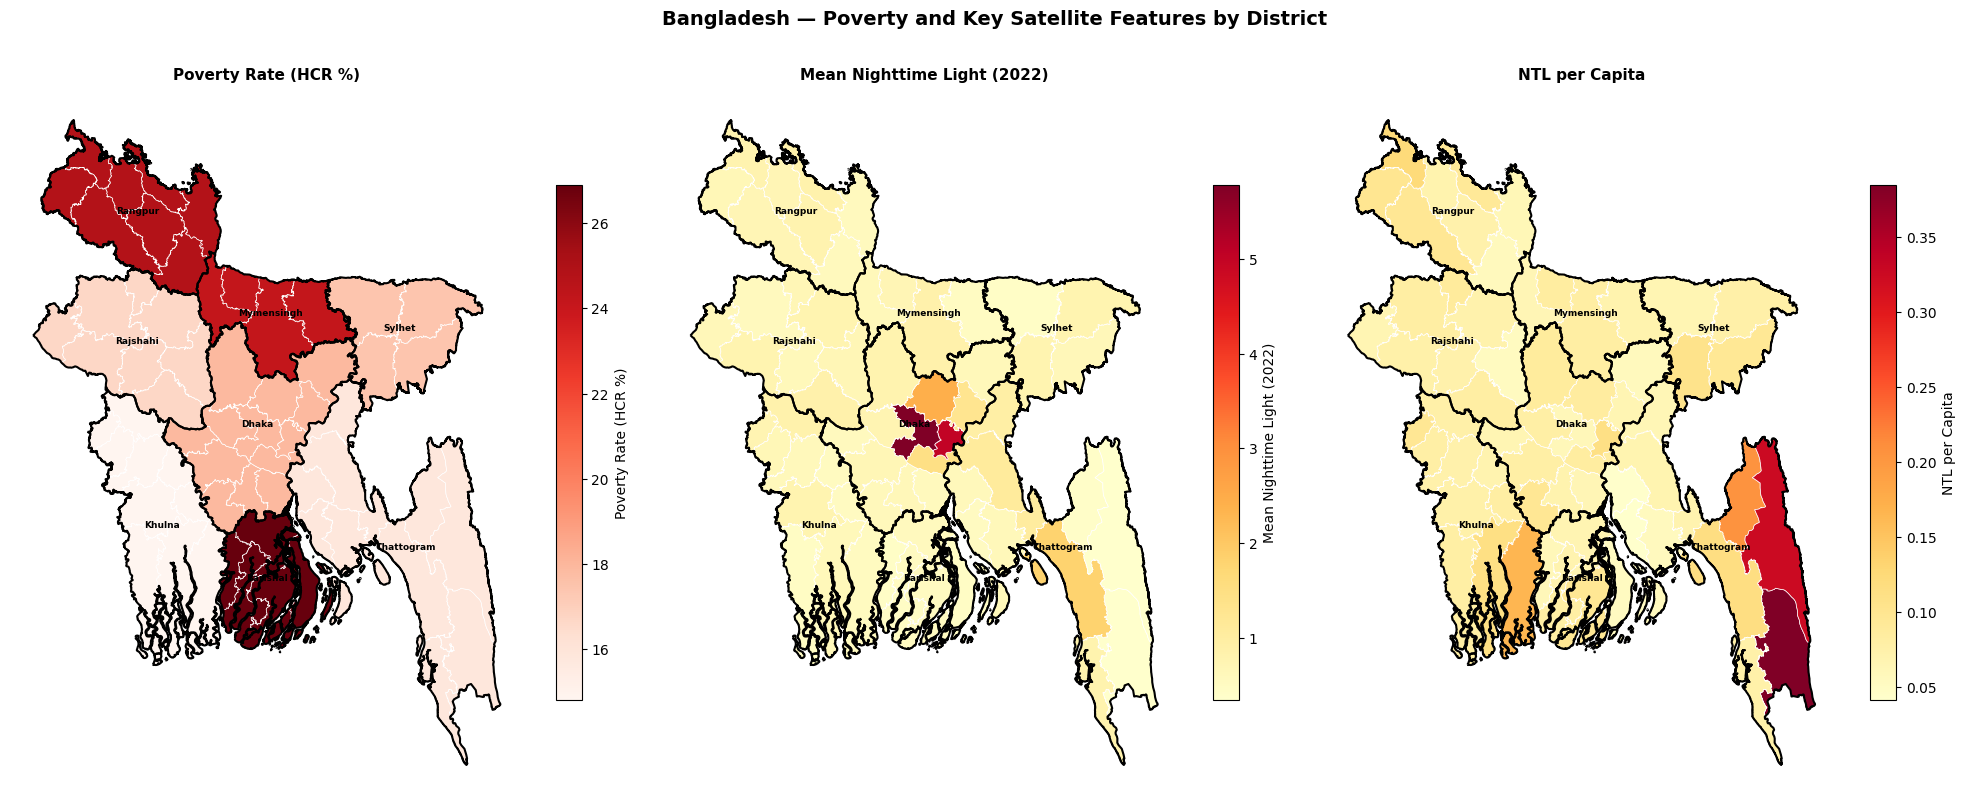

Saved: outputs/maps/poverty_ntl_choropleth.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Bangladesh — Poverty and Key Satellite Features by District',
             fontsize=14, fontweight='bold', y=1.02)

maps = [
    ('poverty_hcr',     'Poverty Rate (HCR %)',         'Reds'),
    ('ntl_mean',        'Mean Nighttime Light (2022)',   'YlOrRd'),
    ('ntl_per_capita',  'NTL per Capita',                'YlOrRd'),
]

for ax, (col, title, cmap) in zip(axes, maps):
    gdf.plot(column=col, cmap=cmap, linewidth=0.5,
             edgecolor='white', legend=True, ax=ax,
             legend_kwds={'shrink': 0.7, 'label': title})
    
    # Division boundaries overlay
    division_boundaries = gdf.dissolve(by='division_name')
    division_boundaries.boundary.plot(ax=ax, linewidth=1.5, 
                                       edgecolor='black')
    
    # Division labels
    for div, row in division_boundaries.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(div, xy=(centroid.x, centroid.y),
                    ha='center', fontsize=6.5, fontweight='bold',
                    color='black')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("outputs/maps/poverty_ntl_choropleth.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/maps/poverty_ntl_choropleth.png")

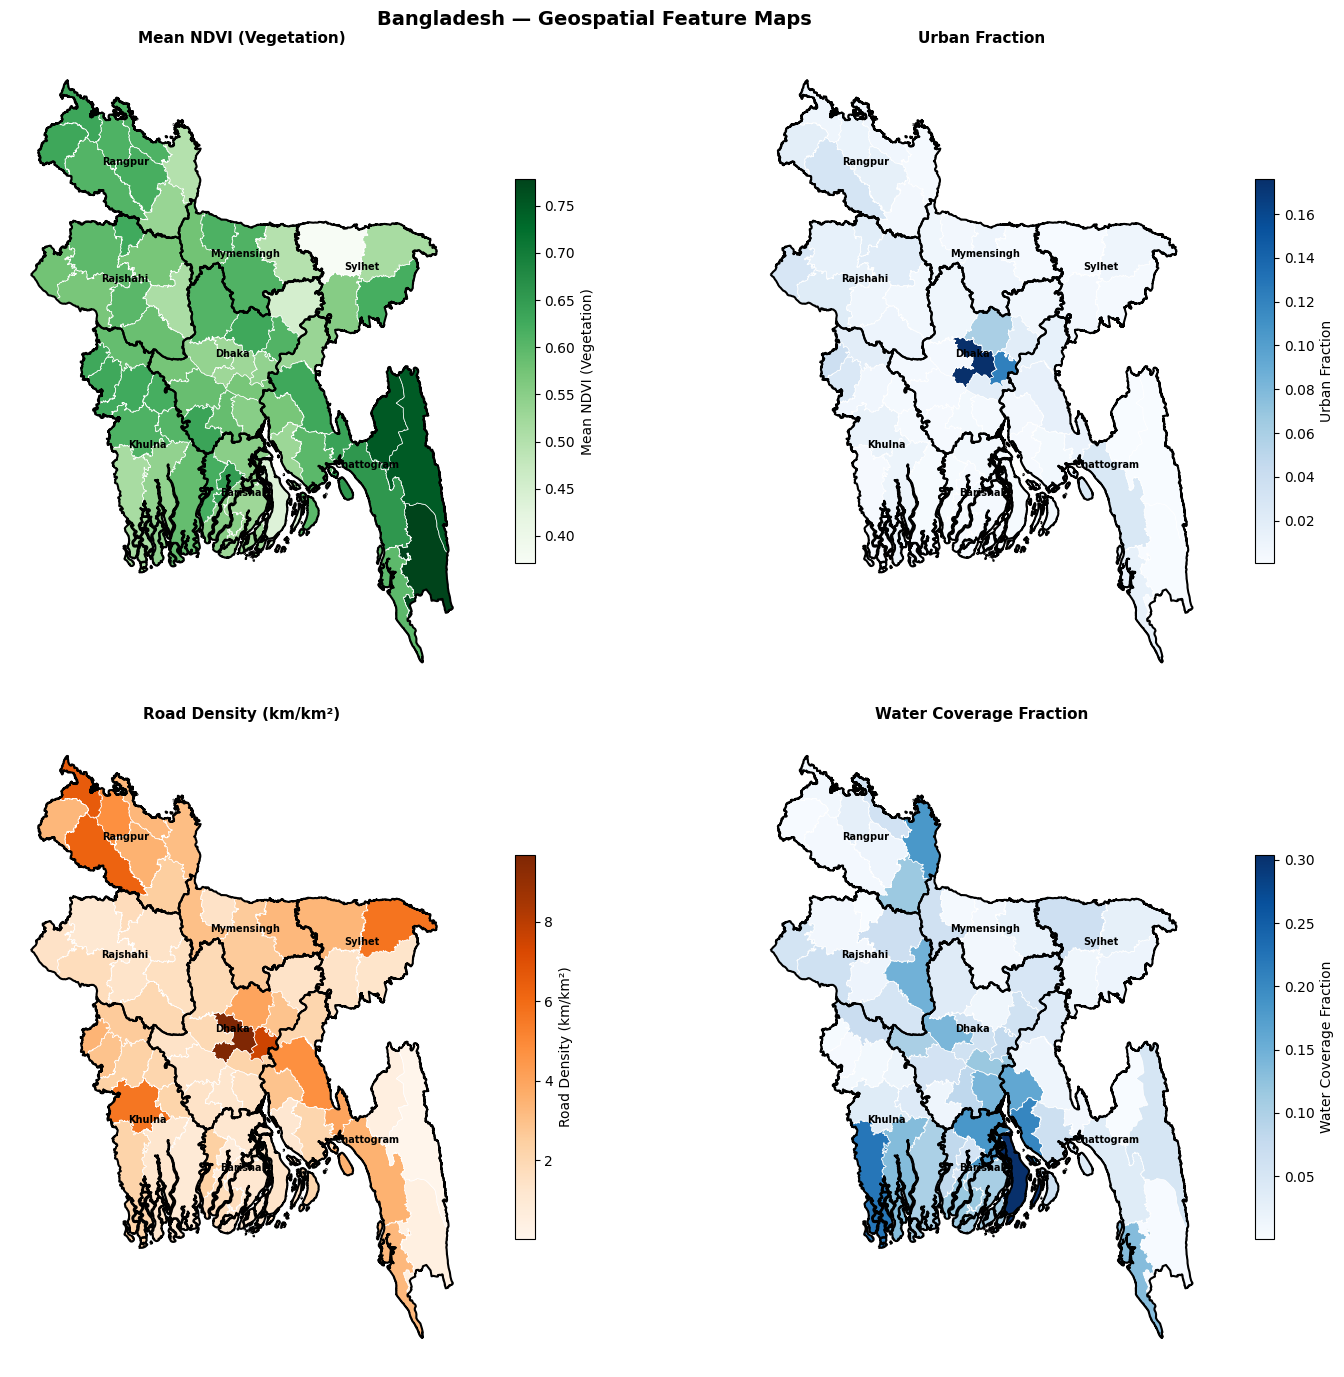

Saved: outputs/maps/feature_maps.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Bangladesh — Geospatial Feature Maps',
             fontsize=14, fontweight='bold')

maps = [
    ('ndvi_mean',       'Mean NDVI (Vegetation)',        'Greens'),
    ('urban_fraction',  'Urban Fraction',                'Blues'),
    ('road_density',    'Road Density (km/km²)',         'Oranges'),
    ('water_fraction',  'Water Coverage Fraction',       'Blues'),
]

division_boundaries = gdf.dissolve(by='division_name')

for ax, (col, title, cmap) in zip(axes.flatten(), maps):
    gdf.plot(column=col, cmap=cmap, linewidth=0.5,
             edgecolor='white', legend=True, ax=ax,
             legend_kwds={'shrink': 0.6, 'label': title})
    division_boundaries.boundary.plot(ax=ax, linewidth=1.5,
                                       edgecolor='black')
    for div, row in division_boundaries.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(div, xy=(centroid.x, centroid.y),
                    ha='center', fontsize=7, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("outputs/maps/feature_maps.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/maps/feature_maps.png")

In [8]:
from scipy import stats
import numpy as np

feature_cols = [
    'ntl_mean', 'ntl_per_capita', 'ntl_trend',
    'pop_density', 'ndvi_mean', 'urban_fraction',
    'water_fraction', 'elevation_mean', 'road_density'
]

print("=== OUTLIER DETECTION (Z-score > 2.5) ===\n")
outliers_found = []

for col in feature_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > 2.5][['district_name', 'division_name', col]]

    if len(outliers) > 0:
        for idx, row in outliers.iterrows():
            outliers_found.append({
                'district': row['district_name'],
                'division': row['division_name'],
                'feature': col,
                'value': round(row[col], 3),
                'z_score': round(z_scores[idx], 2)
            })

        print(f"{col}:")
        print(outliers.to_string(index=False))
        print()

if not outliers_found:
    print("No significant outliers found.")
else:
    print(f"Total outlier instances: {len(outliers_found)}")

=== OUTLIER DETECTION (Z-score > 2.5) ===

ntl_mean:
district_name division_name  ntl_mean
        Dhaka         Dhaka  5.781373
  Narayanganj         Dhaka  5.002248

ntl_per_capita:
district_name division_name  ntl_per_capita
    Bandarban    Chattogram        0.384385
    Rangamati    Chattogram        0.324508

ntl_trend:
district_name division_name  ntl_trend
        Dhaka         Dhaka   0.389592
  Narayanganj         Dhaka   0.348708

pop_density:
district_name division_name  pop_density
        Dhaka         Dhaka    95.921957
  Narayanganj         Dhaka    44.809230

ndvi_mean:
district_name division_name  ndvi_mean
    Bandarban    Chattogram   0.778095
 Khagrachhari    Chattogram   0.751043
    Sunamganj        Sylhet   0.370662

urban_fraction:
district_name division_name  urban_fraction
        Dhaka         Dhaka        0.175827
  Narayanganj         Dhaka        0.122374

water_fraction:
district_name division_name  water_fraction
        Bhola      Barishal        0.303

In [12]:
summary_cols = [
    'ntl_mean', 'ntl_per_capita', 'ntl_trend',
    'pop_density', 'ndvi_mean', 'urban_fraction',
    'water_fraction', 'elevation_mean', 'road_density',
    'poverty_hcr'
]

rename_map = {
    'ntl_mean':       'NTL Mean',
    'ntl_per_capita': 'NTL per Capita',
    'ntl_trend':      'NTL Trend (2018-22)',
    'pop_density':    'Population Density',
    'ndvi_mean':      'NDVI Mean',
    'urban_fraction': 'Urban Fraction',
    'water_fraction': 'Water Fraction',
    'elevation_mean': 'Elevation Mean (m)',
    'road_density':   'Road Density (km/km²)',
    'poverty_hcr':    'Poverty HCR (%)'
}

summary = df[summary_cols].describe().T[['mean','std','min','max']]
summary.index = [rename_map[i] for i in summary.index]
summary.columns = ['Mean', 'Std Dev', 'Min', 'Max']
summary = summary.round(3)

print("=== DESCRIPTIVE STATISTICS TABLE (for paper) ===\n")
print(summary.to_string())

# Save as CSV for your paper
summary.to_csv("D:/Projects/Poverty Predictor Bd/notebooks/outputs/tables/descriptive_stats.csv")
print("\nSaved: outputs/tables/descriptive_stats.csv")

=== DESCRIPTIVE STATISTICS TABLE (for paper) ===

                         Mean  Std Dev     Min      Max
NTL Mean                0.873    0.883   0.341    5.781
NTL per Capita          0.089    0.055   0.041    0.384
NTL Trend (2018-22)     0.043    0.062   0.012    0.390
Population Density     11.284   12.354   0.929   95.922
NDVI Mean               0.585    0.066   0.371    0.778
Urban Fraction          0.015    0.027   0.000    0.176
Water Fraction          0.066    0.063   0.000    0.304
Elevation Mean (m)     21.859   31.373   4.237  193.433
Road Density (km/km²)   2.585    1.775   0.023    9.679
Poverty HCR (%)        18.973    4.196  14.800   26.900

Saved: outputs/tables/descriptive_stats.csv


In [13]:
import libpysal
from esda.moran import Moran
import geopandas as gpd

# Build spatial weights matrix (queen contiguity)
w = libpysal.weights.Queen.from_dataframe(gdf)
w.transform = 'r'  # row-standardize

# Test spatial autocorrelation for key variables
variables = {
    'poverty_hcr':    'Poverty HCR',
    'ntl_mean':       'NTL Mean',
    'ntl_per_capita': 'NTL per Capita',
    'ndvi_mean':      'NDVI Mean',
    'pop_density':    'Population Density',
}

print("=== MORAN'S I SPATIAL AUTOCORRELATION TEST ===")
print("(Positive I = similar values cluster together)")
print("(p < 0.05 = statistically significant spatial pattern)\n")
print(f"{'Variable':<25} {'Moran I':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 60)

for col, label in variables.items():
    moran = Moran(gdf[col], w)
    sig = "YES ***" if moran.p_sim < 0.05 else "no"
    print(f"{label:<25} {moran.I:>10.4f} {moran.p_sim:>10.4f} {sig:>12}")

C:\Users\Raiyan\AppData\Local\Temp\ipykernel_12708\3924689130.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)


=== MORAN'S I SPATIAL AUTOCORRELATION TEST ===
(Positive I = similar values cluster together)
(p < 0.05 = statistically significant spatial pattern)

Variable                     Moran I    p-value  Significant
------------------------------------------------------------
Poverty HCR                   0.7335     0.0010      YES ***
NTL Mean                      0.3199     0.0070      YES ***
NTL per Capita                0.4597     0.0010      YES ***
NDVI Mean                     0.4689     0.0010      YES ***
Population Density            0.2530     0.0010      YES ***


In [14]:
import libpysal
import numpy as np

# Rebuild weights on the full gdf
w = libpysal.weights.Queen.from_dataframe(gdf)
w.transform = 'r'

# Compute spatial lag for key features
# (weighted average of neighboring districts' values)
lag_features = ['ntl_mean', 'ntl_per_capita', 'ndvi_mean', 'pop_density']

for feat in lag_features:
    lag_col = f'{feat}_spatial_lag'
    gdf[lag_col] = libpysal.weights.lag_spatial(w, gdf[feat])
    df[lag_col]  = gdf[lag_col].values
    print(f"Added: {lag_col}")

# Quick check
print(f"\nDataset shape after spatial lag features: {df.shape}")
print(df[['district_name'] + [f'{f}_spatial_lag' for f in lag_features]].head(8))

C:\Users\Raiyan\AppData\Local\Temp\ipykernel_12708\3618719583.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)


Added: ntl_mean_spatial_lag
Added: ntl_per_capita_spatial_lag
Added: ndvi_mean_spatial_lag
Added: pop_density_spatial_lag

Dataset shape after spatial lag features: (64, 30)
  district_name  ntl_mean_spatial_lag  ntl_per_capita_spatial_lag  \
0       Barguna              0.519397                    0.092072   
1      Barishal              0.530254                    0.074449   
2         Bhola              0.561730                    0.065223   
3     Jhalokati              0.484289                    0.069671   
4    Patuakhali              0.487487                    0.067223   
5      Pirojpur              0.536719                    0.096137   
6     Bandarban              0.995970                    0.171976   
7  Brahmanbaria              1.758925                    0.081835   

   ndvi_mean_spatial_lag  pop_density_spatial_lag  
0               0.586765                 6.362451  
1               0.570093                 7.335630  
2               0.551281                 9.51245

In [15]:
import os
os.makedirs("outputs/tables", exist_ok=True)

# Save updated master with spatial lag features
df.to_csv("D:/Projects/Poverty Predictor Bd/data/processed/master_features.csv", index=False)
gdf.to_file("D:/Projects/Poverty Predictor Bd/data/processed/master_features.gpkg", driver="GPKG")

print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nAll features:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col}")

Final dataset: 64 rows, 30 columns

All features:
   1. district_name
   2. division_name
   3. ntl_mean
   4. ntl_std
   5. ntl_max
   6. ntl_min
   7. ntl_p25
   8. ntl_p75
   9. ntl_yoy_change
  10. ntl_trend
  11. pop_density
  12. pop_total
  13. ndvi_mean
  14. ndvi_std
  15. urban_fraction
  16. water_fraction
  17. elevation_mean
  18. elevation_std
  19. road_length_km
  20. poverty_hcr
  21. poverty_hcr_lower
  22. poverty_change
  23. ntl_per_capita
  24. area_sqkm
  25. road_density
  26. ntl_iqr
  27. ntl_mean_spatial_lag
  28. ntl_per_capita_spatial_lag
  29. ndvi_mean_spatial_lag
  30. pop_density_spatial_lag
